# Lab 06 – Hough Transform, SIFT & Wavelets
**FAST NUCES – Karachi**

| # | Task | Technique |
|---|------|-----------|
| 1 | Computer screen detection in a computer lab | Hough Line Transform |
| 2 | Asset tracking in a computer lab | SIFT |
| 3 | Anomaly detection in sensor data | Wavelet transform |
| 4 | Object recognition (using video) | SIFT + RANSAC |
| 5 | Your panoramic image | SIFT + homography stitching |
| 6 | Lane detection | Hough Line Transform |
| 7 | Coins detection and counting | Hough Circle Transform |
| 8 | Smart security system | Boundary (contour) detection |

**Note on data:** no image/video files were supplied with the lab sheet, so every task builds its own *synthetic* test data (clearly marked in each section). Each task has a path variable near the top – point it to your own image/video and the same pipeline runs on it.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
print("OpenCV version:", cv2.__version__)

try:
    import pywt
    HAS_PYWT = True
except ImportError:           # Task 3 falls back to a hand-written Haar wavelet
    HAS_PYWT = False
print("PyWavelets available:", HAS_PYWT)

def show(img, title="", figsize=(8, 5)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_grid(imgs, titles, cols=3, size=(5, 3.6)):
    rows = (len(imgs) + cols - 1) // cols
    plt.figure(figsize=(size[0] * cols, size[1] * rows))
    for i, (im, t) in enumerate(zip(imgs, titles)):
        plt.subplot(rows, cols, i + 1)
        if im.ndim == 2:
            plt.imshow(im, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(t, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def make_texture(w, h, seed, label="", n_shapes=40):
    # Feature-rich synthetic image (blobs, rectangles, text) so SIFT has plenty of keypoints
    rng = np.random.RandomState(seed)
    small = rng.randint(50, 210, (h // 10 + 2, w // 10 + 2, 3)).astype(np.uint8)
    img = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
    for _ in range(n_shapes):
        c = tuple(int(v) for v in rng.randint(0, 255, 3))
        p = (int(rng.randint(0, w)), int(rng.randint(0, h)))
        if rng.rand() < 0.5:
            cv2.circle(img, p, int(rng.randint(4, 22)), c, -1)
        else:
            q = (p[0] + int(rng.randint(8, 40)), p[1] + int(rng.randint(8, 40)))
            cv2.rectangle(img, p, q, c, -1)
    if label:
        cv2.putText(img, label, (10, h // 2), cv2.FONT_HERSHEY_DUPLEX,
                    min(w, h) / 110, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.rectangle(img, (0, 0), (w - 1, h - 1), (0, 0, 0), 4)
    return img

OpenCV version: 4.13.0
PyWavelets available: True


---
## Task 1 – Computer Screen Detection in a Computer Lab (Hough Line Transform)


Screen (row 1, col 1) at (81, 120, 278, 242): ON
Screen (row 1, col 2) at (351, 120, 546, 242): OFF
Screen (row 1, col 3) at (622, 120, 820, 242): ON
Screen (row 2, col 1) at (81, 371, 278, 493): OFF
Screen (row 2, col 2) at (351, 371, 546, 493): ON
ANOMALY: no screen at row 2, col 3

Detected 5 / 6 screens (3 ON, 2 OFF, 1 missing)


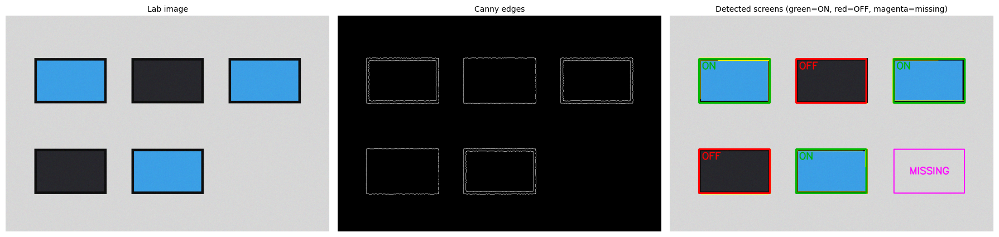

In [2]:
EXPECTED_ROWS, EXPECTED_COLS = 2, 3
LAB_IMAGE_PATH = None   # e.g. "lab.jpg" to use your own photo

def make_lab_image(rows=EXPECTED_ROWS, cols=EXPECTED_COLS, missing=((1, 2),), off=((0, 1), (1, 0)),
                   W=900, H=600):
    img = np.full((H, W, 3), 215, np.uint8)                       # light wall
    sw, sh = 200, 125
    xs = np.linspace(W * 0.2, W * 0.8, cols).astype(int)
    ys = np.linspace(H * 0.30, H * 0.72, rows).astype(int)
    for r, cy in enumerate(ys):
        for c, cx in enumerate(xs):
            if (r, c) in missing:
                continue
            x1, y1 = cx - sw // 2, cy - sh // 2
            x2, y2 = x1 + sw, y1 + sh
            cv2.rectangle(img, (x1, y1), (x2, y2), (15, 15, 15), -1)               # bezel
            col = (45, 40, 40) if (r, c) in off else (230, 160, 60)             # OFF / ON
            cv2.rectangle(img, (x1 + 7, y1 + 7), (x2 - 7, y2 - 7), col, -1)
    noise = np.random.normal(0, 4, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

def cluster_1d(vals, tol=14):
    vals = sorted(vals)
    if not vals:
        return []
    groups = [[vals[0]]]
    for v in vals[1:]:
        if v - groups[-1][-1] <= tol:
            groups[-1].append(v)
        else:
            groups.append([v])
    return [float(np.mean(g)) for g in groups]

def side_support(edges_dil, x1, y1, x2, y2):
    def frac(pts):
        return np.mean([edges_dil[int(np.clip(y, 0, edges_dil.shape[0] - 1)),
                                  int(np.clip(x, 0, edges_dil.shape[1] - 1))] > 0 for x, y in pts])
    top = frac([(x, y1) for x in np.linspace(x1, x2, 40)])
    bot = frac([(x, y2) for x in np.linspace(x1, x2, 40)])
    lef = frac([(x1, y) for y in np.linspace(y1, y2, 40)])
    rig = frac([(x2, y) for y in np.linspace(y1, y2, 40)])
    return min(top, bot, lef, rig)

def detect_screens(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=60, minLineLength=80, maxLineGap=10)
    horiz, vert = [], []
    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        ang = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
        if ang < 5 or ang > 175:
            horiz.append((y1 + y2) / 2)
        elif 85 < ang < 95:
            vert.append((x1 + x2) / 2)
    ys, xs = cluster_1d(horiz), cluster_1d(vert)
    edges_dil = cv2.dilate(edges, np.ones((13, 13), np.uint8))
    screens = []
    for i in range(len(ys)):
        for j in range(i + 1, len(ys)):
            for k in range(len(xs)):
                for l in range(k + 1, len(xs)):
                    w, h = xs[l] - xs[k], ys[j] - ys[i]
                    if 120 < w < 320 and 70 < h < 200 and 1.2 < w / h < 2.2:
                        if side_support(edges_dil, xs[k], ys[i], xs[l], ys[j]) > 0.8:
                            screens.append((int(xs[k]), int(ys[i]), int(xs[l]), int(ys[j])))
    return screens, edges, lines

def screen_status(img, box, thresh=90):
    x1, y1, x2, y2 = box
    mx, my = int((x2 - x1) * 0.2), int((y2 - y1) * 0.2)
    roi = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)[y1 + my:y2 - my, x1 + mx:x2 - mx]
    return "ON" if roi.mean() > thresh else "OFF"

lab_img = cv2.imread(LAB_IMAGE_PATH) if LAB_IMAGE_PATH else make_lab_image()
screens, edges, lines = detect_screens(lab_img)

# group detections into the grid and find the empty slots
cx = [(b[0] + b[2]) / 2 for b in screens]
cy = [(b[1] + b[3]) / 2 for b in screens]
col_c, row_c = cluster_1d(cx, 40), cluster_1d(cy, 40)
w_med = int(np.median([b[2] - b[0] for b in screens]))
h_med = int(np.median([b[3] - b[1] for b in screens]))

result = lab_img.copy()
for lx1, ly1, lx2, ly2 in lines.reshape(-1, 4):
    cv2.line(result, (lx1, ly1), (lx2, ly2), (0, 255, 255), 1)
found_slots = set()
for b in screens:
    status = screen_status(lab_img, b)
    colour = (0, 180, 0) if status == "ON" else (0, 0, 255)
    cv2.rectangle(result, (b[0], b[1]), (b[2], b[3]), colour, 3)
    cv2.putText(result, status, (b[0] + 8, b[1] + 28), cv2.FONT_HERSHEY_SIMPLEX, 0.9, colour, 2)
    r = int(np.argmin([abs((b[1] + b[3]) / 2 - v) for v in row_c]))
    c = int(np.argmin([abs((b[0] + b[2]) / 2 - v) for v in col_c]))
    found_slots.add((r, c))
    print(f"Screen (row {r+1}, col {c+1}) at {b}: {status}")

missing_slots = [(r, c) for r in range(len(row_c)) for c in range(len(col_c)) if (r, c) not in found_slots]
for r, c in missing_slots:
    mx_, my_ = int(col_c[c]), int(row_c[r])
    cv2.rectangle(result, (mx_ - w_med // 2, my_ - h_med // 2), (mx_ + w_med // 2, my_ + h_med // 2), (255, 0, 255), 2)
    cv2.putText(result, "MISSING", (mx_ - 55, my_ + 8), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 255), 2)
    print(f"ANOMALY: no screen at row {r+1}, col {c+1}")
total_expected = EXPECTED_ROWS * EXPECTED_COLS
print(f"\nDetected {len(screens)} / {total_expected} screens "
      f"({sum(screen_status(lab_img, b) == 'ON' for b in screens)} ON, "
      f"{sum(screen_status(lab_img, b) == 'OFF' for b in screens)} OFF, "
      f"{total_expected - len(screens)} missing)")

show_grid([lab_img, edges, result], ["Lab image", "Canny edges", "Detected screens (green=ON, red=OFF, magenta=missing)"],
          cols=3, size=(6, 4.2))

---
## Task 2 – Asset Tracking in a Computer Lab Using SIFT


Monitor   good matches= 147  RANSAC inliers= 146  ->  FOUND
Keyboard  good matches= 104  RANSAC inliers= 103  ->  FOUND
CPU       good matches=  88  RANSAC inliers=  87  ->  FOUND
Mouse     good matches=  47  RANSAC inliers=  47  ->  FOUND
Printer   good matches=   5  RANSAC inliers=   0  ->  NOT FOUND

=== INVENTORY REPORT ===
[x] Monitor
[x] Keyboard
[x] CPU
[x] Mouse
[ ] Printer
4 of 5 assets located


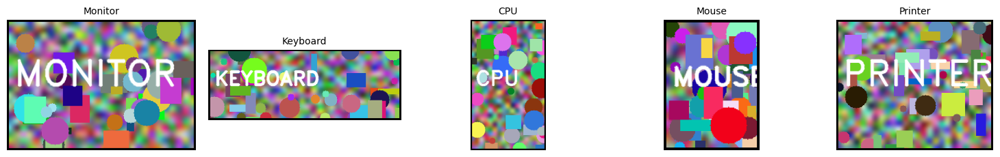

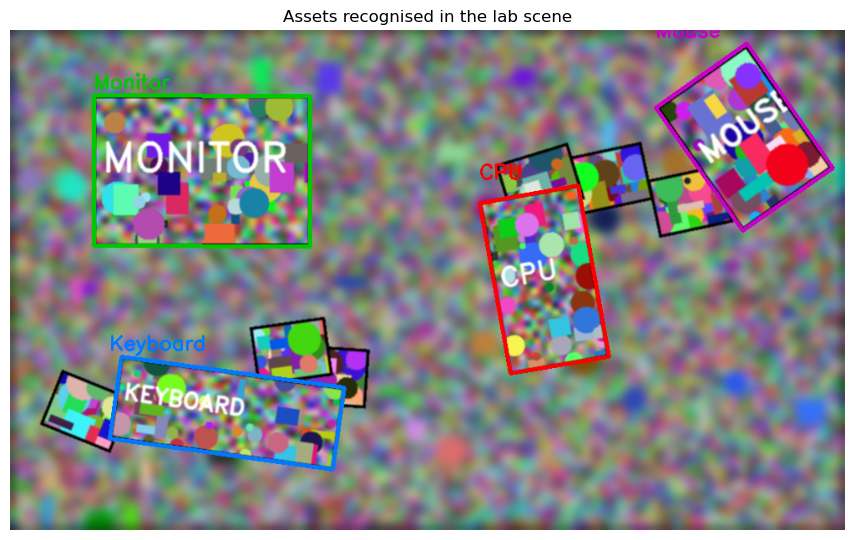

In [3]:
sift = cv2.SIFT_create()

def place(scene, tpl, center, scale, angle):
    h, w = tpl.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[:, 2] += (np.array(center) - np.array([w / 2, h / 2]))
    warped = cv2.warpAffine(tpl, M, (scene.shape[1], scene.shape[0]))
    mask = cv2.warpAffine(np.full((h, w), 255, np.uint8), M, (scene.shape[1], scene.shape[0]))
    scene[mask > 0] = warped[mask > 0]

assets = {
    "Monitor":  make_texture(260, 180, 1, "MONITOR"),
    "Keyboard": make_texture(300, 110, 2, "KEYBOARD"),
    "CPU":      make_texture(150, 260, 3, "CPU"),
    "Mouse":    make_texture(110, 150, 4, "MOUSE"),
    "Printer":  make_texture(240, 200, 5, "PRINTER"),
}

# lab scene: smooth background + distractor clutter + placed assets
scene = cv2.GaussianBlur(make_texture(1000, 600, 99, n_shapes=60), (0, 0), 6)
for s in range(6):
    place(scene, make_texture(90, 70, 200 + s), (int(np.random.randint(60, 940)), int(np.random.randint(50, 550))), 1.0, int(np.random.randint(-30, 30)))
place(scene, assets["Monitor"],  (230, 170), 1.0, 0)
place(scene, assets["Keyboard"], (260, 460), 0.9, -8)
place(scene, assets["CPU"],      (640, 300), 0.8, 10)
place(scene, assets["Mouse"],    (880, 130), 1.2, 35)
scene = cv2.GaussianBlur(scene, (3, 3), 0)

def find_asset(tpl, scene, ratio=0.75, min_inliers=10):
    k1, d1 = sift.detectAndCompute(cv2.cvtColor(tpl, cv2.COLOR_BGR2GRAY), None)
    k2, d2 = sift.detectAndCompute(cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY), None)
    knn = cv2.BFMatcher().knnMatch(d1, d2, k=2)
    good = [m for m, n in (p for p in knn if len(p) == 2) if m.distance < ratio * n.distance]
    if len(good) < min_inliers:
        return None, len(good), 0
    src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if H is None or int(mask.sum()) < min_inliers:
        return None, len(good), 0 if mask is None else int(mask.sum())
    h, w = tpl.shape[:2]
    box = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), H)
    return box, len(good), int(mask.sum())

inventory = {}
annotated = scene.copy()
palette = [(0, 200, 0), (255, 120, 0), (0, 0, 255), (200, 0, 200), (0, 200, 200)]
for (name, tpl), colour in zip(assets.items(), palette):
    box, n_good, n_inl = find_asset(tpl, scene)
    inventory[name] = box is not None
    if box is not None:
        cv2.polylines(annotated, [np.int32(box)], True, colour, 3)
        x, y = np.int32(box).reshape(-1, 2).min(0)
        cv2.putText(annotated, name, (int(x), int(y) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, colour, 2)
    print(f"{name:9s} good matches={n_good:4d}  RANSAC inliers={n_inl:4d}  ->  {'FOUND' if box is not None else 'NOT FOUND'}")

print("\n=== INVENTORY REPORT ===")
for name, ok in inventory.items():
    print(f"[{'x' if ok else ' '}] {name}")
print(f"{sum(inventory.values())} of {len(inventory)} assets located")

show_grid(list(assets.values()), list(assets.keys()), cols=5, size=(3, 2.4))
show(annotated, "Assets recognised in the lab scene", figsize=(11, 6.5))

---
## Task 3 – Anomaly Detection in Sensor Data Using Wavelet Transformation


Wavelet: db4 (PyWavelets),  detail threshold = 3.63
Residual std = 1.010,  anomaly threshold = +/-2.02
Anomalies detected: 42
Injected spikes recovered: [150, 330, 520, 700, 880] of [150, 330, 520, 700, 880]


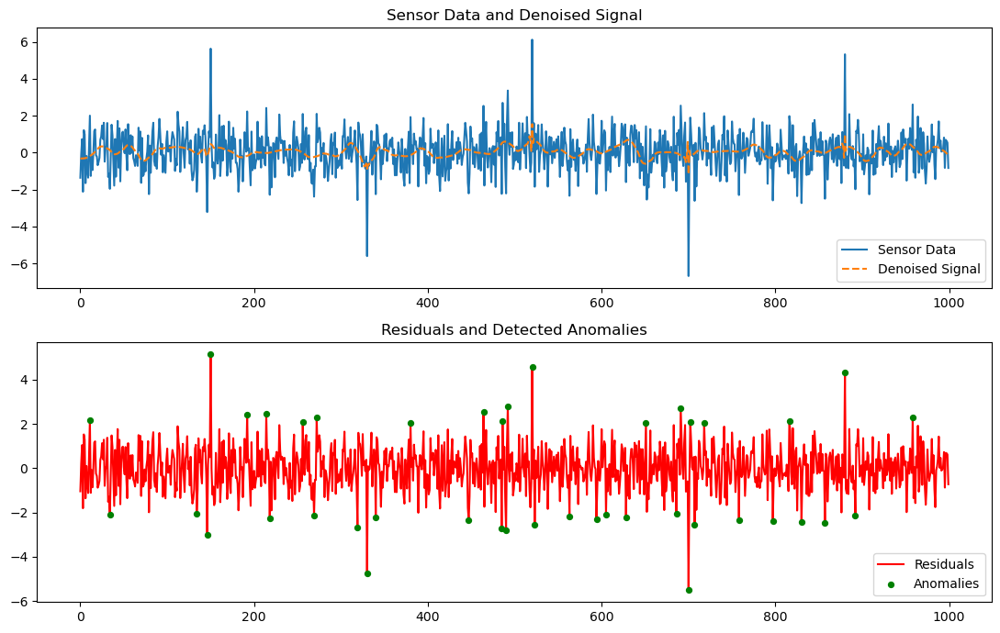

In [4]:
def haar_wavedec(x, level):
    coeffs, a = [], np.asarray(x, float)
    for _ in range(level):
        if len(a) % 2:
            a = np.append(a, a[-1])
        coeffs.append((a[0::2] - a[1::2]) / np.sqrt(2))
        a = (a[0::2] + a[1::2]) / np.sqrt(2)
    return [a] + coeffs[::-1]

def haar_waverec(coeffs):
    a = coeffs[0]
    for d in coeffs[1:]:
        a = a[:len(d)]
        out = np.empty(2 * len(d))
        out[0::2] = (a + d) / np.sqrt(2)
        out[1::2] = (a - d) / np.sqrt(2)
        a = out
    return a

def wavelet_denoise(x):
    n = len(x)
    if HAS_PYWT:
        coeffs = pywt.wavedec(x, "db4", level=4)
    else:
        coeffs = haar_wavedec(x, 3)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    thr = sigma * np.sqrt(2 * np.log(n))
    den = [coeffs[0]] + [np.sign(c) * np.maximum(np.abs(c) - thr, 0) for c in coeffs[1:]]
    rec = pywt.waverec(den, "db4") if HAS_PYWT else haar_waverec(den)
    return rec[:n], thr

n = 1000
sensor = np.random.randn(n)
spike_idx = [150, 330, 520, 700, 880]
sensor[spike_idx] += np.array([5, -5, 6, -5.5, 5])      # injected machine faults

denoised, thr = wavelet_denoise(sensor)
residual = sensor - denoised
anom_idx = np.where(np.abs(residual) > 2 * residual.std())[0]

print(f"Wavelet: {'db4 (PyWavelets)' if HAS_PYWT else 'Haar (built-in)'},  detail threshold = {thr:.2f}")
print(f"Residual std = {residual.std():.3f},  anomaly threshold = +/-{2 * residual.std():.2f}")
print(f"Anomalies detected: {len(anom_idx)}")
print("Injected spikes recovered:", [i for i in spike_idx if i in anom_idx], "of", spike_idx)

fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(sensor, label="Sensor Data")
ax[0].plot(denoised, "--", label="Denoised Signal")
ax[0].set_title("Sensor Data and Denoised Signal"); ax[0].legend(loc="lower right")
ax[1].plot(residual, "r", label="Residuals")
ax[1].scatter(anom_idx, residual[anom_idx], c="g", s=18, label="Anomalies", zorder=3)
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

---
## Task 4 – Object Recognition (Using Video) with SIFT


Frames loaded: 60
Object recognised in 60 / 60 frames
Frames 30-44 (partial occlusion): recognised in 15 / 15


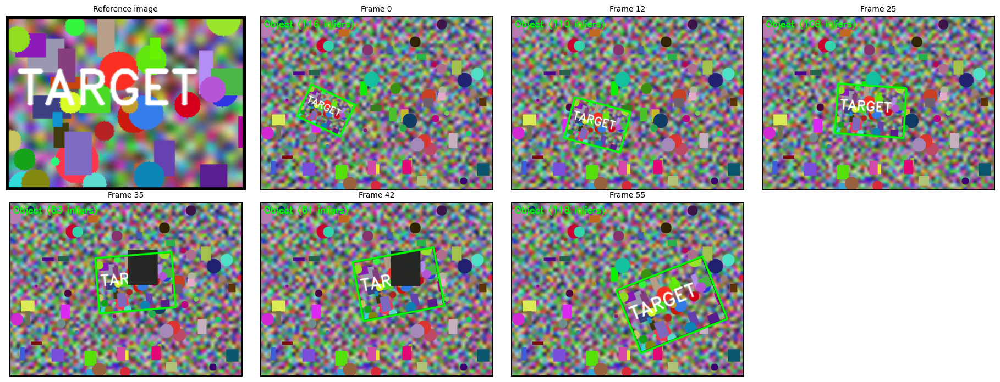

In [5]:
VIDEO_PATH = None      # e.g. "my_video.mp4"
REF_PATH = None        # e.g. "reference.jpg"

reference = cv2.imread(REF_PATH) if REF_PATH else make_texture(220, 160, 7, "TARGET")

def build_synthetic_video(path="object_video.mp4", n_frames=60, size=(640, 480)):
    bg = make_texture(size[0], size[1], 123, n_shapes=70)
    frames = []
    for t in range(n_frames):
        f = bg.copy()
        scale = 0.6 + 0.6 * t / (n_frames - 1)
        angle = -25 + 50 * t / (n_frames - 1)
        cx, cy = 180 + 280 * t / (n_frames - 1), 260 + 40 * np.sin(t / 8)
        place(f, reference, (cx, cy), scale, angle)
        if 30 <= t < 45:                                   # partial occlusion
            cv2.rectangle(f, (int(cx) - 20, int(cy) - 90), (int(cx) + 60, int(cy) + 5), (40, 40, 40), -1)
        frames.append(f)
    vw = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"mp4v"), 15, size)
    if vw.isOpened():
        for f in frames:
            vw.write(f)
    vw.release()
    return path, frames

def read_video(path):
    cap = cv2.VideoCapture(path)
    out = []
    while True:
        ok, f = cap.read()
        if not ok:
            break
        out.append(f)
    cap.release()
    return out

if VIDEO_PATH:
    video_frames = read_video(VIDEO_PATH)
else:
    path, synthetic = build_synthetic_video()
    video_frames = read_video(path) or synthetic       # fall back to in-memory frames if codec missing
print("Frames loaded:", len(video_frames))

ref_kp, ref_des = sift.detectAndCompute(cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY), None)
bf = cv2.BFMatcher()
rh, rw = reference.shape[:2]
ref_corners = np.float32([[0, 0], [rw, 0], [rw, rh], [0, rh]]).reshape(-1, 1, 2)

def recognise(frame, ratio=0.75, min_inliers=10):
    kp, des = sift.detectAndCompute(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), None)
    if des is None or len(kp) < 2:
        return frame, False, 0
    knn = bf.knnMatch(ref_des, des, k=2)
    good = [m for m, n in (p for p in knn if len(p) == 2) if m.distance < ratio * n.distance]
    out = frame.copy()
    if len(good) >= min_inliers:
        src = np.float32([ref_kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if H is not None and mask.sum() >= min_inliers:
            box = cv2.perspectiveTransform(ref_corners, H)
            cv2.polylines(out, [np.int32(box)], True, (0, 255, 0), 3, cv2.LINE_AA)
            cv2.putText(out, f"Object ({int(mask.sum())} inliers)", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            return out, True, int(mask.sum())
    cv2.putText(out, "Not found", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    return out, False, 0

results = [recognise(f) for f in video_frames]
detected = [r[1] for r in results]
print(f"Object recognised in {sum(detected)} / {len(detected)} frames")
occluded = [i for i in range(30, min(45, len(detected)))]
if len(detected) >= 45:
    print(f"Frames 30-44 (partial occlusion): recognised in {sum(detected[i] for i in occluded)} / {len(occluded)}")

# save annotated video
h0, w0 = video_frames[0].shape[:2]
vw = cv2.VideoWriter("object_recognition_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 15, (w0, h0))
for r in results:
    vw.write(r[0])
vw.release()

pick = [0, 12, 25, 35, 42, 55]
pick = [p for p in pick if p < len(results)]
show_grid([reference] + [results[i][0] for i in pick], ["Reference image"] + [f"Frame {i}" for i in pick], cols=4, size=(4.6, 3.5))

---
## Task 5 – Your Panoramic Image (SIFT stitching)



Stitching with SIFT + homography:
 adding image 2   381 good matches, 381 inliers
 adding image 3   339 good matches, 338 inliers
 adding image 4   314 good matches, 314 inliers
Panorama size: 1590 x 438


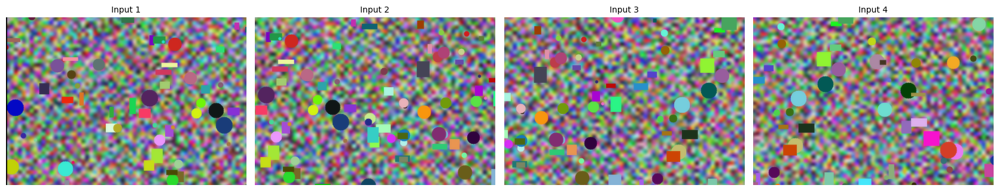

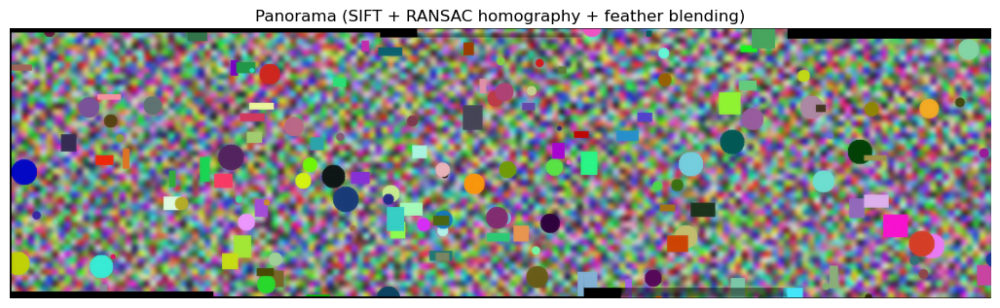

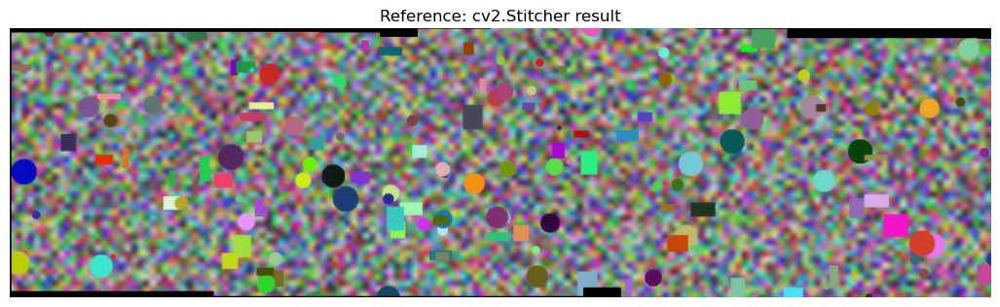

In [6]:
PANO_PATHS = None      # e.g. ["p1.jpg", "p2.jpg", "p3.jpg", "p4.jpg"]

if PANO_PATHS:
    pano_imgs = [cv2.imread(p) for p in PANO_PATHS]
else:
    wide = make_texture(1600, 480, 321, n_shapes=160)
    wide = cv2.addWeighted(wide, 0.85, cv2.GaussianBlur(wide, (0, 0), 3), 0.15, 0)
    shifts = [0, 8, -6, 10]
    pano_imgs = []
    for i, dy in enumerate(shifts):
        x0, y0 = i * 330, 20 + dy
        pano_imgs.append(wide[y0:y0 + 420, x0:x0 + 600].copy())

def stitch_pair(base, new, ratio=0.75):
    kb, db = sift.detectAndCompute(cv2.cvtColor(base, cv2.COLOR_BGR2GRAY), None)
    kn, dn = sift.detectAndCompute(cv2.cvtColor(new, cv2.COLOR_BGR2GRAY), None)
    knn = cv2.BFMatcher().knnMatch(dn, db, k=2)
    good = [m for m, n in (p for p in knn if len(p) == 2) if m.distance < ratio * n.distance]
    print(f"   {len(good)} good matches", end="")
    src = np.float32([kn[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kb[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
    print(f", {int(mask.sum())} inliers")
    hb, wb = base.shape[:2]
    hn, wn = new.shape[:2]
    cn = cv2.perspectiveTransform(np.float32([[0, 0], [wn, 0], [wn, hn], [0, hn]]).reshape(-1, 1, 2), H)
    cb = np.float32([[0, 0], [wb, 0], [wb, hb], [0, hb]]).reshape(-1, 1, 2)
    allc = np.concatenate([cn, cb])
    xmin, ymin = np.floor(allc.min(axis=(0, 1))).astype(int)
    xmax, ymax = np.ceil(allc.max(axis=(0, 1))).astype(int)
    T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], float)
    size = (int(xmax - xmin), int(ymax - ymin))
    warped = cv2.warpPerspective(new, T @ H, size).astype(np.float32)
    canvas = cv2.warpPerspective(base, T, size).astype(np.float32)
    m_new = cv2.warpPerspective(np.full((hn, wn), 255, np.uint8), T @ H, size)
    m_base = cv2.warpPerspective(np.full((hb, wb), 255, np.uint8), T, size)
    w_new = cv2.distanceTransform(m_new, cv2.DIST_L2, 3)[..., None]
    w_base = cv2.distanceTransform(m_base, cv2.DIST_L2, 3)[..., None]
    out = (canvas * w_base + warped * w_new) / (w_base + w_new + 1e-6)
    return np.clip(out, 0, 255).astype(np.uint8)

def crop_black(img):
    ys, xs = np.where(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) > 0)
    return img[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

print("Stitching with SIFT + homography:")
panorama = pano_imgs[0]
for i, nxt in enumerate(pano_imgs[1:], start=2):
    print(f" adding image {i}", end="")
    panorama = stitch_pair(panorama, nxt)
panorama = crop_black(panorama)
print("Panorama size:", panorama.shape[1], "x", panorama.shape[0])

show_grid(pano_imgs, [f"Input {i+1}" for i in range(len(pano_imgs))], cols=4, size=(4.2, 3.2))
show(panorama, "Panorama (SIFT + RANSAC homography + feather blending)", figsize=(13, 4.5))

try:
    status, builtin = cv2.Stitcher_create(cv2.Stitcher_PANORAMA).stitch(pano_imgs)
    if status == cv2.Stitcher_OK:
        show(builtin, "Reference: cv2.Stitcher result", figsize=(13, 4.5))
    else:
        print("cv2.Stitcher status code:", status)
except Exception as e:
    print("cv2.Stitcher skipped:", e)

---
## Task 6 – Lane Detection using the Hough Line Transform


Image 1: 6 left segments, 6 right segments -> both lanes found
Image 2: 7 left segments, 5 right segments -> both lanes found
Image 3: 6 left segments, 4 right segments -> both lanes found


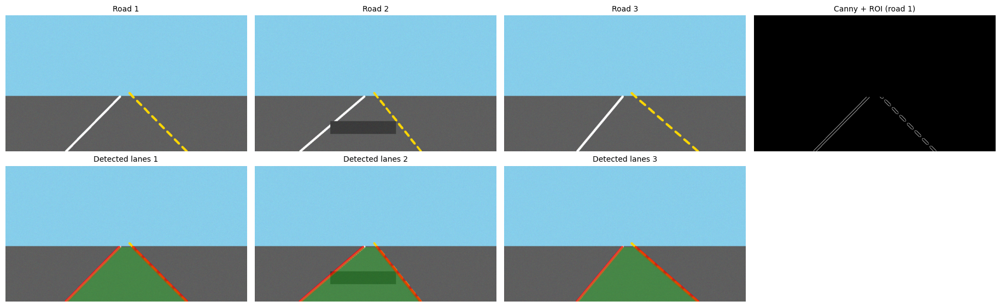

In [7]:
ROAD_PATHS = None      # e.g. ["road1.jpg", "road2.jpg"]

def make_road(shift=0, shadow=False, W=960, H=540):
    img = np.zeros((H, W, 3), np.uint8)
    horizon = 320
    img[:horizon] = (235, 206, 135)                          # sky
    img[horizon:] = (95, 95, 95)                             # asphalt
    vx = W // 2 + shift // 3
    cv2.line(img, (240 + shift, H), (vx - 25, horizon + 2), (255, 255, 255), 8)       # left: solid white
    p0, p1 = np.array([720 + shift, H]), np.array([vx + 25, horizon + 2])
    for t in np.arange(0, 1, 0.14):                                                   # right: dashed yellow
        a, b = p0 + (p1 - p0) * t, p0 + (p1 - p0) * (t + 0.08)
        cv2.line(img, tuple(a.astype(int)), tuple(b.astype(int)), (0, 215, 255), 8)
    if shadow:
        cv2.rectangle(img, (300, 420), (560, 470), (60, 60, 60), -1)
    noise = np.random.normal(0, 6, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

def detect_lanes(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    roi = np.zeros_like(edges)
    cv2.fillPoly(roi, [np.array([(100, h), (w - 100, h), (int(w * 0.56), int(h * 0.6)), (int(w * 0.44), int(h * 0.6))])], 255)
    edges_roi = cv2.bitwise_and(edges, roi)
    lines = cv2.HoughLinesP(edges_roi, 1, np.pi / 180, threshold=40, minLineLength=40, maxLineGap=60)
    left, right = [], []
    for x1, y1, x2, y2 in (lines.reshape(-1, 4) if lines is not None else []):
        if x2 == x1:
            continue
        slope = (y2 - y1) / (x2 - x1)
        if abs(slope) < 0.4:
            continue                                         # drop near-horizontal segments
        (left if slope < 0 else right).append((x1, y1, x2, y2))
    out = img.copy()
    overlay = img.copy()
    y_top, y_bot = int(h * 0.6), h
    fits = []
    for side in (left, right):
        if not side:
            continue
        ys = np.array([[l[1], l[3]] for l in side]).ravel()
        xs = np.array([[l[0], l[2]] for l in side]).ravel()
        m, b = np.polyfit(ys, xs, 1)                         # x = m*y + b
        pts = ((int(m * y_bot + b), y_bot), (int(m * y_top + b), y_top))
        cv2.line(overlay, pts[0], pts[1], (0, 0, 255), 10)
        fits.append(pts)
    out = cv2.addWeighted(overlay, 0.8, out, 0.2, 0)
    if len(fits) == 2:                                       # shade the lane between the lines
        lane = np.array([fits[0][0], fits[0][1], fits[1][1], fits[1][0]])
        shade = out.copy()
        cv2.fillPoly(shade, [lane], (0, 255, 0))
        out = cv2.addWeighted(shade, 0.25, out, 0.75, 0)
    return out, edges_roi, (len(left), len(right))

road_imgs = [cv2.imread(p) for p in ROAD_PATHS] if ROAD_PATHS else [make_road(0), make_road(-60, shadow=True), make_road(50)]
lane_results = [detect_lanes(im) for im in road_imgs]
for i, (_, _, (nl, nr)) in enumerate(lane_results, 1):
    print(f"Image {i}: {nl} left segments, {nr} right segments -> {'both lanes found' if nl and nr else 'lane missing'}")

show_grid(road_imgs + [r[1] for r in lane_results[:1]] + [r[0] for r in lane_results],
          [f"Road {i+1}" for i in range(len(road_imgs))] + ["Canny + ROI (road 1)"] + [f"Detected lanes {i+1}" for i in range(len(road_imgs))],
          cols=4, size=(4.6, 2.9))

---
## Task 7 – Coins Detection and Counting (Hough Circle Transform)


Image 1: detected 8 coins {'small': 4, 'medium': 3, 'large': 1}  (ground truth = 8)
Image 2: detected 12 coins {'small': 3, 'medium': 5, 'large': 4}  (ground truth = 12)


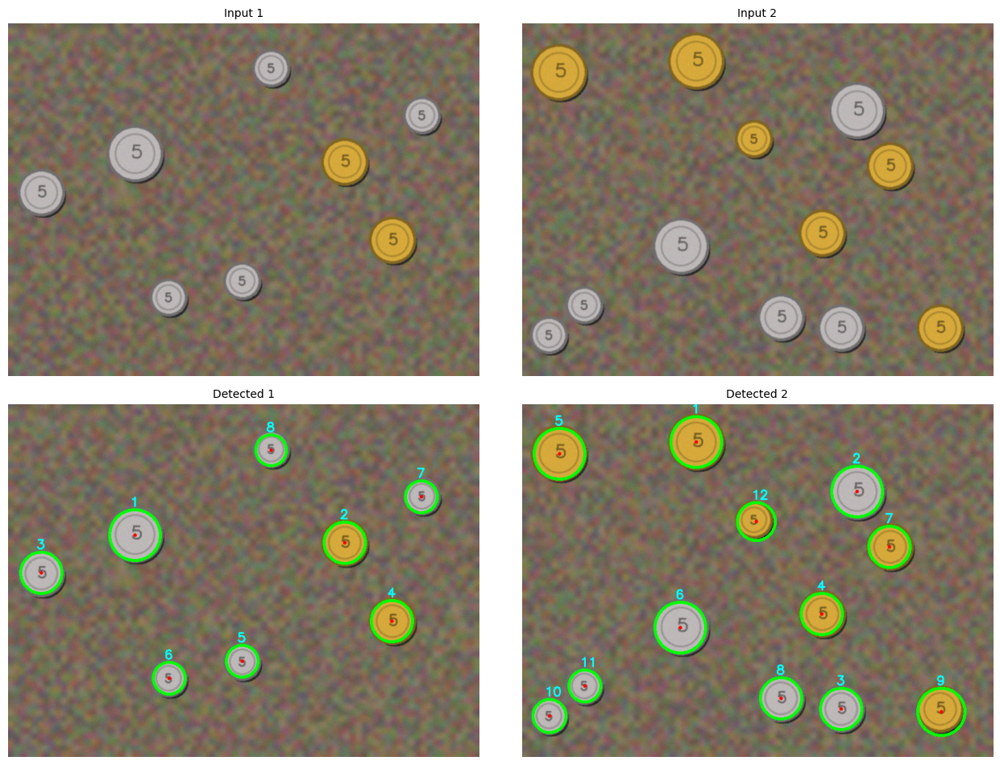

In [8]:
COIN_PATHS = None      # e.g. ["coins1.jpg", "coins2.jpg"]

def make_coins(n, seed):
    rng = np.random.RandomState(seed)
    bg = rng.randint(100, 140, (60, 80, 3)).astype(np.uint8)
    img = cv2.resize(bg, (800, 600), interpolation=cv2.INTER_CUBIC)
    img = (img * np.array([0.75, 0.9, 1.0])).astype(np.uint8)          # brownish table
    placed = []
    tries = 0
    while len(placed) < n and tries < 5000:
        tries += 1
        r = int(rng.choice([30, 38, 46]))
        x, y = int(rng.randint(r + 10, 800 - r - 10)), int(rng.randint(r + 10, 600 - r - 10))
        if all(np.hypot(x - px, y - py) > r + pr + 12 for px, py, pr in placed):
            placed.append((x, y, r))
    for x, y, r in placed:
        base = (60, 170, 215) if rng.rand() < 0.5 else (185, 185, 190)  # gold / silver
        cv2.circle(img, (x + 4, y + 5), r, (40, 40, 40), -1)            # soft shadow
        cv2.circle(img, (x, y), r, base, -1)
        cv2.circle(img, (x, y), r, tuple(int(c * 0.6) for c in base), 3)
        cv2.circle(img, (x, y), int(r * 0.72), tuple(int(c * 0.8) for c in base), 2)
        cv2.putText(img, "5", (x - 7, y + 7), cv2.FONT_HERSHEY_SIMPLEX, r / 45, tuple(int(c * 0.55) for c in base), 2)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    noise = rng.normal(0, 4, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8), len(placed)

def detect_coins(img):
    gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 7)
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=45,
                               param1=100, param2=40, minRadius=24, maxRadius=52)
    out = img.copy()
    if circles is None:
        return out, []
    circles = np.round(circles[0]).astype(int)
    for i, (x, y, r) in enumerate(circles, 1):
        cv2.circle(out, (x, y), r, (0, 255, 0), 3)
        cv2.circle(out, (x, y), 3, (0, 0, 255), -1)
        cv2.putText(out, str(i), (x - 8, y - r - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    return out, circles

if COIN_PATHS:
    coin_imgs = [(cv2.imread(p), None) for p in COIN_PATHS]
else:
    coin_imgs = [make_coins(8, 1), make_coins(12, 2)]

coin_out = []
for i, (im, truth) in enumerate(coin_imgs, 1):
    out, circ = detect_coins(im)
    coin_out.append(out)
    sizes = {"small": 0, "medium": 0, "large": 0}
    for _, _, r in circ:
        sizes["small" if r < 34 else "medium" if r < 42 else "large"] += 1
    msg = f"Image {i}: detected {len(circ)} coins {sizes}"
    if truth is not None:
        msg += f"  (ground truth = {truth})"
    print(msg)

show_grid([c[0] for c in coin_imgs] + coin_out,
          [f"Input {i+1}" for i in range(len(coin_imgs))] + [f"Detected {i+1}" for i in range(len(coin_imgs))],
          cols=2, size=(6.5, 4.8))

---
## Task 8 – Smart Security System (boundary detection in a security zone)


*** ALARM triggered at frame 51 ***
Alarm active in 39 of 90 frames


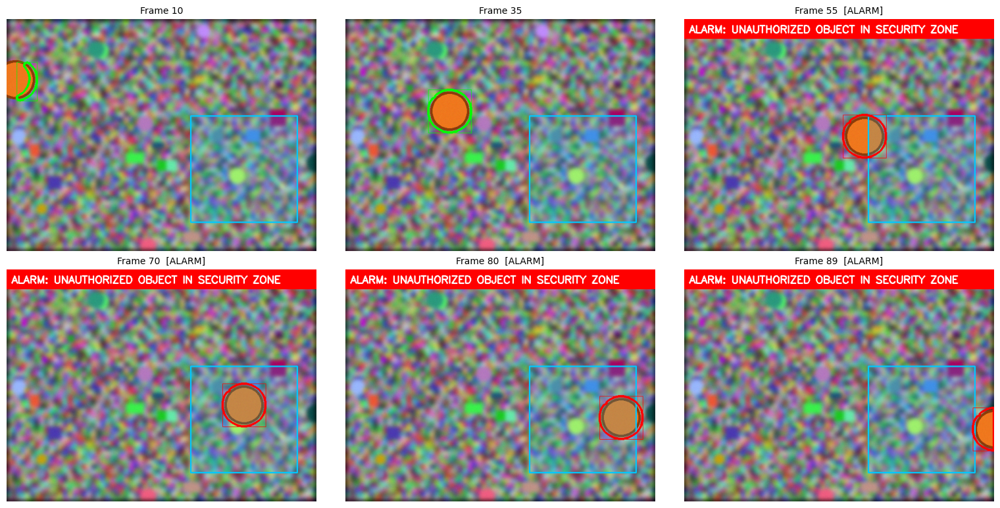

In [9]:
ZONE = np.array([[380, 200], [600, 200], [600, 420], [380, 420]])     # security zone polygon
MIN_OVERLAP_PX = 150

def make_stream(n=90, size=(640, 480)):
    bg = cv2.GaussianBlur(make_texture(size[0], size[1], 77, n_shapes=30), (0, 0), 4)
    frames = []
    for t in range(n):
        f = bg.copy()
        x, y = -60 + 700 * t / (n - 1), 100 + 230 * t / (n - 1)            # starts off-screen, walks into the zone
        cv2.circle(f, (int(x), int(y)), 38, (30, 120, 240), -1)
        cv2.circle(f, (int(x), int(y)), 38, (10, 60, 140), 3)
        noise = np.random.normal(0, 3, f.shape)
        frames.append(np.clip(f + noise, 0, 255).astype(np.uint8))
    return frames

class ZoneMonitor:
    def __init__(self, zone, min_overlap=MIN_OVERLAP_PX):
        self.zone, self.min_overlap = zone, min_overlap
        self.bgs = cv2.createBackgroundSubtractorMOG2(history=60, varThreshold=40, detectShadows=False)
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    def warm_up(self, frames):
        for f in frames:
            self.bgs.apply(f)

    def process(self, frame):
        fg = self.bgs.apply(frame)
        fg = cv2.medianBlur(fg, 5)
        fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, self.kernel)
        fg = cv2.dilate(fg, self.kernel, iterations=2)
        contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        zone_mask = np.zeros(frame.shape[:2], np.uint8)
        cv2.fillPoly(zone_mask, [self.zone], 255)
        out = frame.copy()
        shade = out.copy()
        cv2.fillPoly(shade, [self.zone], (255, 200, 0))
        out = cv2.addWeighted(shade, 0.18, out, 0.82, 0)
        cv2.polylines(out, [self.zone], True, (255, 200, 0), 2)
        alarm = False
        for c in contours:
            if cv2.contourArea(c) < 500:
                continue
            obj = np.zeros(frame.shape[:2], np.uint8)
            cv2.drawContours(obj, [c], -1, 255, -1)
            inside = cv2.countNonZero(cv2.bitwise_and(obj, zone_mask)) > self.min_overlap
            colour = (0, 0, 255) if inside else (0, 255, 0)
            cv2.drawContours(out, [c], -1, colour, 3)
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(out, (x, y), (x + w, y + h), colour, 1)
            alarm = alarm or inside
        if alarm:
            cv2.rectangle(out, (0, 0), (frame.shape[1], 40), (0, 0, 255), -1)
            cv2.putText(out, "ALARM: UNAUTHORIZED OBJECT IN SECURITY ZONE", (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        return out, alarm

stream = make_stream()
monitor = ZoneMonitor(ZONE)
monitor.warm_up(stream[:12])                    # first frames are empty -> background model

processed, alarms = [], []
for t, f in enumerate(stream):
    out, a = monitor.process(f)
    processed.append(out)
    alarms.append(a)
    if a and (t == 0 or not alarms[t - 1]):
        print(f"*** ALARM triggered at frame {t} ***")
print(f"Alarm active in {sum(alarms)} of {len(alarms)} frames")

idx = [10, 35, 55, 70, 80, 89]
show_grid([processed[i] for i in idx], [f"Frame {i}" + ("  [ALARM]" if alarms[i] else "") for i in idx], cols=3, size=(5.2, 3.9))

def run_live(source=0):
    # Real-time version: source=0 for webcam or a video file path. Press 'q' to quit.
    cap = cv2.VideoCapture(source)
    mon = ZoneMonitor(ZONE)
    for _ in range(30):                                   # warm-up on the empty scene
        ok, f = cap.read()
        if ok:
            mon.bgs.apply(f)
    while True:
        ok, f = cap.read()
        if not ok:
            break
        out, a = mon.process(f)
        if a:
            print("\a", end="")                           # terminal beep
        cv2.imshow("Smart Security System", out)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release()
    cv2.destroyAllWindows()